
## Minimum Norm Solution






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

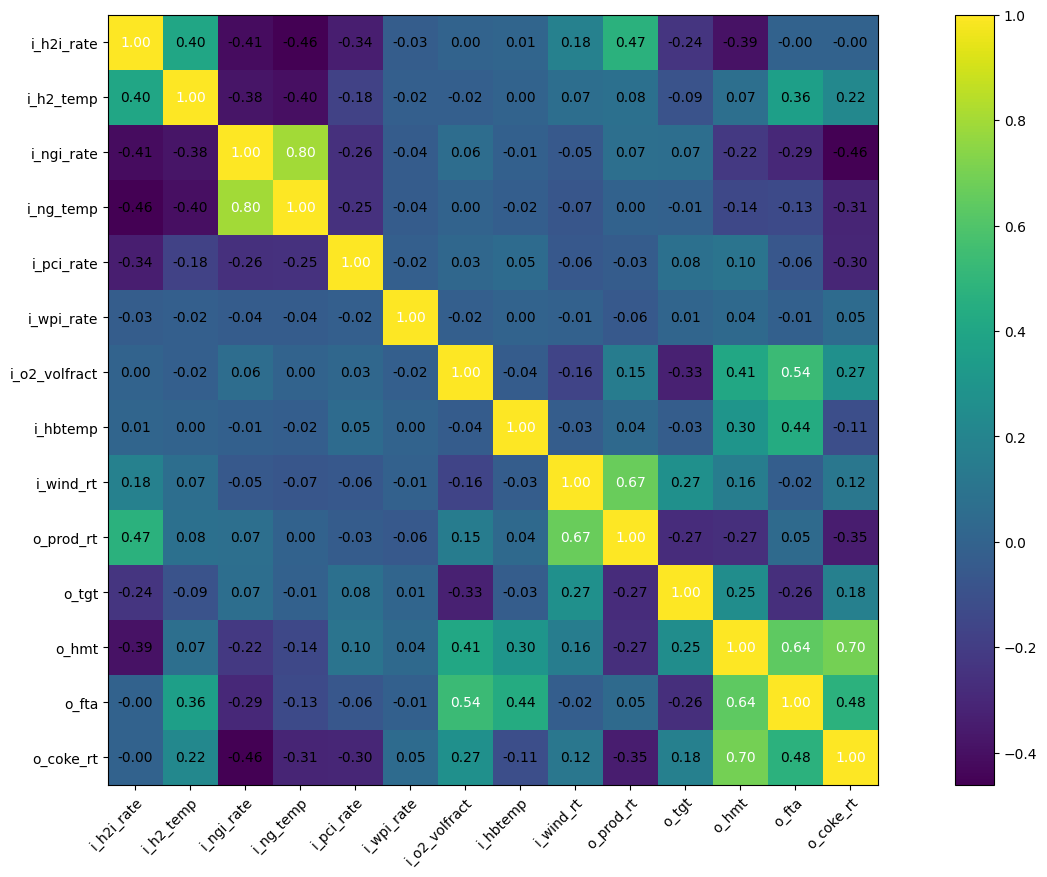

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']


PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 5 components
pca = PCA(n_components=5)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca





In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 5)
(1000, 5)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 5     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 5     ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.9812305569648743
100 ..... 0.5858845114707947
200 ..... 0.5408419966697693
300 ..... 0.25076979398727417
400 ..... 0.9358662962913513
500 ..... 0.8535851836204529
600 ..... 0.7652794122695923
700 ..... 0.4477340579032898
800 ..... 0.8105107545852661
900 ..... 0.5807852149009705


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  98.2742, 1292.1134, 8433.8340, 2304.0730,  417.1343]])
y_deviations: tensor([[  51.2593,  525.9562, 1519.8474,  212.0064,   50.1178]])
x_means: tensor([[    -0.0000,     -0.0000,     -0.0000,      0.0000,     -0.0000]])
x_deviations: tensor([[272.1895, 158.2895,  50.7683,  35.9862,  26.3602]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.0149,  766.1572, 6913.9863, 2092.0667,  367.0166]])
tensor([[ 149.5334, 1818.0696, 9953.6816, 2516.0793,  467.2521]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[-272.1895, -158.2895,  -50.7683,  -35.9862,  -26.3602]])
tensor([[272.1895, 158.2895,  50.7683,  35.9862,  26.3602]])



## Is model  invertible ?

* use the Jacobian


In [29]:

import torch
from torch.autograd.functional import jacobian


In [30]:

## x = torch.randn(1, 7, requires_grad=True)

x = torch.randn(      7, requires_grad=True)  # shape [7]

x = torch.randn(      5, requires_grad=True)  # shape [7]


In [31]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  # Only return 1 tensor to get a clean Jacobian




In [32]:

## J = jacobian(model_Forward, x)

J = jacobian(wrapped_model, x)


In [33]:

print( len(J) )


1


In [34]:


print( J.shape )  # Should be [1, 4, 7]


torch.Size([1, 5, 5])


In [35]:

u, s, v = torch.svd(J)  


In [36]:

rank = (s > 1e-5).sum()


In [37]:


print("Local Jacobian rank:", rank.item())


Local Jacobian rank: 5



## Example of Min Norm Solution



## Approach


In [38]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)


In [39]:


def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x







In [40]:



x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')



torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.70925189    0.           55.99011223   26.20739637  271.00270753
 1488.23869858  161.9459715 ]
real
[  12.50866602   12.01454991   42.10202425   25.58749493  299.91510668
 1479.96443201  194.02273566]
1
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.13752019    0.           55.73533617   26.18465746  305.52133462
 1500.64727876  163.256796  ]
real
[   4.87708586   60.79195144   40.83291937   25.67339346  299.96809945
 1479.98363301  194.55975477]
2
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1,

torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.47339201    0.           57.27610144   26.18228727  248.99324091
 1508.58116161  162.22505169]
real
[   0.            0.          149.37504162   26.02140731  300.02336856
 1448.01302117  195.34762292]
28
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.56939227    0.           49.84300958   26.10834826  225.39210102
 1520.4953133   163.56655347]
real
[  29.7848776     3.19942109    3.35156066   25.00109437 1199.86813805
 1599.93872935  228.33537771]
29
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([

torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.71337951    0.           51.64015767   26.17716605  296.93247207
 1479.90231368  163.43722691]
real
[  20.16301157    1.64741553    1.72974906   25.61586162  299.93299398
 1199.9669975   194.10884062]
52
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.71766039    0.           59.38567761   26.20170334  330.93379656
 1458.36170115  165.50075431]
real
[  17.32958641   43.79643124    2.92339823   24.73236796  299.88339834
 1599.94862923  228.5962323 ]
53
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.17206839    0.           60.90063554   26.31900357  473.32459319
 1416.52026321  164.32254721]
real
[  27.80793793    0.            0.           25.70225913 1200.01276689
 1480.01064797  195.27591832]
91
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.65181611    0.           61.84120869   26.25881023  399.21825376
 1431.85437657  165.5687265 ]
real
[  13.99502811    2.25650784   62.35710315   24.8951187   299.9054976
 1599.95922072  228.88308937]
92
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  1

torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.64320211    0.           58.82463477   26.28990042  357.6980086
 1455.96496045  161.36947323]
real
[  10.97560953    1.76508255   42.83912121   26.25752558  299.92503334
 1447.96978146  159.16593291]
116
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.85018107    0.           55.26058536   26.22284208  279.6215905
 1488.21164995  161.12434007]
real
[   7.59648192    0.           67.8991712    26.29573752  300.08269826
 1480.03834952  161.04212879]
117
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([

...

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   8.97097042    0.           57.31069658   26.13326713  167.25383093
 1521.72870856  162.62082572]
real
[   0.          149.47279644    0.           25.89198624  300.02217363
 1200.00937625  195.25740296]
893
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.51780787    0.           52.7059649    26.11162458  255.20886152
 1496.46743574  165.56158664]
real
[   9.1735622     0.           88.18387345   25.28125878  300.07376358
 1200.03018291  230.83161437]
894
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[

torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.83172553    0.           63.23922677   26.27991331  455.34056044
 1415.17131208  166.60884219]
real
[  12.91204996   72.08150455    2.17390023   24.78087414  299.9127337
 1599.96251379  228.97307806]
914
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.19206298    0.           59.00461267   26.26070324  288.81612232
 1483.33602616  160.3716962 ]
real
[   2.58983869    0.           98.72023245   26.33910427  300.04719006
 1600.0275375   160.73207405]
915
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbt

torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.89865074    0.           54.09871895   26.2030458   253.7807076
 1479.30677796  161.75829348]
real
[  22.64124615    0.4175925     0.42782167   25.70883093  599.98063713
 1199.99549013  194.86473868]
950
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.36099354    0.           59.5681491    26.34594941  485.35174834
 1422.80126365  162.57492614]
real
[  24.77395151    0.7614889     0.7870758    26.28972739 1199.9662476
 1599.98926236  159.69429294]
951
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([

torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.37611081    0.           54.77393026   26.17726721  312.90408394
 1482.8332969   164.33652329]
real
[  29.79244725    3.19440258    3.33999265   24.99996079 1199.86695753
 1599.94110717  228.39173431]
972
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.63602294    0.           55.27715739   26.24769711  391.25097401
 1468.78020108  162.93224649]
real
[   9.75711804   21.58671039   31.67114191   26.22656583  299.93661359
 1479.96636032  159.09796508]
973
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfra

torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   9.71661678    0.           55.53737553   26.22929167  273.19567569
 1493.22684907  160.51068718]
real
[   8.96896367    0.           59.81575195   26.1860189   300.00601387
 1600.0049828   160.12929179]
992
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   8.72347962    0.           57.27301761   26.09181437  116.88774707
 1548.91556062  162.62951528]
real
[   0.          149.66451117    0.           25.5744501   300.01444524
 1600.00541498  195.15089615]
993
********************************
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
torch.Size([1, 5, 5])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfra

In [41]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 263.9729



## Now add Costs


In [42]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_latent = pca.components_ @ price_real

price_latent = torch.tensor(price_latent, dtype=torch.float32)


In [43]:

def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    ##delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01
    
    lambda_cost = 0.01
    
    delta_x = (J_pinv @ delta_y) - lambda_cost * price_latent
    delta_x = 0.01 * delta_x

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x






In [44]:


x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []
dist_method_B = []

cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        # ---- compute cost at this iteration ----
        x_temp_np = x_temp.detach().numpy()
        x_temp_real = pca.inverse_transform(x_temp_np)

        # enforce physical constraint
        x_temp_real = np.maximum(x_temp_real, 0.0)

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
        print("real cost       :", cost_real)
        cost_diff    = cost - cost_real
        percent_diff = (cost - cost_real) / cost_real
        
    percent_diffs.append( percent_diff  )
          
    cost_diffs.append(       cost_diff  )
        
        
        
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred x" )
    print( x_new_solution )
    print( "real x" )
    print( x_real_np_sol )
    
    ##########################################
    
    
    x_new_solution = np.atleast_2d(x_new_solution)
    x_real_np_sol  = np.atleast_2d(x_real_np_sol)

    x_new_pca  = pca.transform(x_new_solution)
    x_real_pca = pca.transform(x_real_np_sol)

    y_pred_rc = wrapped_model(torch.tensor(x_new_pca).float())
    y_real_rc = wrapped_model(torch.tensor(x_real_pca).float())
    
    
    ##########################################
    
    the_cols_y = "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"
        
    print( the_cols_y )
    print( "pred y" )
    print( y_pred_rc )
    print( "real y" )
    print( y_real_rc )
    
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    dist_method_B.append( euclid(
            y_pred_rc.detach().numpy(),
            y_real_rc.detach().numpy()
    ))
    
    print(i)
    print('********************************')




torch.Size([1, 5, 5])
iteration 0 cost: 67.27422422130235...H2, PCI, NGI: [ 9.75758343  0.         56.48778099]
real cost       : 83.10022609946041
torch.Size([1, 5, 5])
iteration 1 cost: 67.17255279494282...H2, PCI, NGI: [ 9.7543492   0.         56.31031201]
real cost       : 83.10022609946041
torch.Size([1, 5, 5])
iteration 2 cost: 67.0613744418546...H2, PCI, NGI: [ 9.74357736  0.         56.17413004]
real cost       : 83.10022609946041
torch.Size([1, 5, 5])
iteration 3 cost: 66.96125116277595...H2, PCI, NGI: [ 9.73597437  0.         56.03470739]
real cost       : 83.10022609946041
torch.Size([1, 5, 5])
iteration 4 cost: 66.85976556822433...H2, PCI, NGI: [ 9.72723246  0.         55.90167149]
real cost       : 83.10022609946041
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   9.72723246    0.           55.90167149   26.20717653  270.77238697
 1488.22813268  161.92934838]
real x
[  12.50866602   12.01454991   42.10202425

torch.Size([1, 5, 5])
iteration 1 cost: 67.91101675114082...H2, PCI, NGI: [10.01983439  0.         55.66335842]
real cost       : 74.79161692927804
torch.Size([1, 5, 5])
iteration 2 cost: 68.18984976035688...H2, PCI, NGI: [10.13884957  0.         55.26890293]
real cost       : 74.79161692927804
torch.Size([1, 5, 5])
iteration 3 cost: 68.41200545472506...H2, PCI, NGI: [10.25104197  0.         54.81567512]
real cost       : 74.79161692927804
torch.Size([1, 5, 5])
iteration 4 cost: 68.64702977691513...H2, PCI, NGI: [10.3613864   0.         54.40296832]
real cost       : 74.79161692927804
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  10.3613864     0.           54.40296832   26.24762582  341.85341925
 1470.33270554  161.66753509]
real x
[  18.19480975    1.32178156    1.38119276   26.04995134  299.94475152
 1479.97593401  159.34160223]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  82.2399, 1105.5352, 6978.515

o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  78.9761, 1233.6128, 6956.8906, 2328.5020,  415.9503]],
       grad_fn=<AddBackward0>)
real y
tensor([[ 107.1717,  921.8318, 8360.8896, 2079.7485,  388.1273]],
       grad_fn=<AddBackward0>)
23
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 67.26753895658543...H2, PCI, NGI: [ 9.71751762  0.         56.79493694]
real cost       : 65.57066810629578
torch.Size([1, 5, 5])
iteration 1 cost: 67.15839848061889...H2, PCI, NGI: [ 9.66899717  0.         56.9648196 ]
real cost       : 65.57066810629578
torch.Size([1, 5, 5])
iteration 2 cost: 67.05261599889553...H2, PCI, NGI: [ 9.61699956  0.         57.16923549]
real cost       : 65.57066810629578
torch.Size([1, 5, 5])
iteration 3 cost: 66.9625279314517...H2, PCI, NGI: [ 9.55818252  0.         57.45959567]
real cost       : 65.57066810629578
torch.Size([1, 5, 5])
iteration 4 cost: 66.85965963712904...H2, PCI, NGI: [ 9.50826488  0.         57.65320023]
real cost  

iteration 3 cost: 67.01329911279055...H2, PCI, NGI: [ 9.88294265  0.         54.96305704]
real cost       : 87.65945779774783
torch.Size([1, 5, 5])
iteration 4 cost: 66.91252901732848...H2, PCI, NGI: [ 9.89945869  0.         54.62938855]
real cost       : 87.65945779774783
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   9.89945869    0.           54.62938855   26.10926061  214.61760068
 1517.06025732  164.42178747]
real x
[  13.56269722    0.           68.90433578   24.88434592  300.04243883
 1600.02091187  230.56461177]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  86.3933, 1258.0186, 6845.8169, 2311.7646,  418.7723]],
       grad_fn=<AddBackward0>)
real y
tensor([[ 113.0928, 1452.7382, 9933.7705, 2345.5305,  409.1116]],
       grad_fn=<AddBackward0>)
33
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 67.97000995207316...H2, PCI, NGI: [ 9.99095657  0.         56.01236738]
real cos

torch.Size([1, 5, 5])
iteration 4 cost: 67.50100653521997...H2, PCI, NGI: [10.53054768  0.         50.75763162]
real cost       : 74.79706316218372
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  10.53054768    0.           50.75763162   26.19006844  264.20410987
 1487.9198748   161.54419353]
real x
[  19.35158317    0.            0.           26.00175738  300.07230123
 1480.0302031   160.83016259]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  77.1936, 1212.0238, 6937.0850, 2320.7986,  417.1503]],
       grad_fn=<AddBackward0>)
real y
tensor([[  66.9905, 1438.3778, 6630.5107, 2408.0117,  464.2240]],
       grad_fn=<AddBackward0>)
51
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 67.6370966904174...H2, PCI, NGI: [ 9.95250883  0.         55.65412276]
real cost       : 83.16433634800207
torch.Size([1, 5, 5])
iteration 1 cost: 67.883921049295...H2, PCI, NGI: [10.13539017  0.         54

...

torch.Size([1, 5, 5])
iteration 1 cost: 68.90724620123814...H2, PCI, NGI: [10.00891736  0.         57.74315353]
real cost       : 100.25083282111846
torch.Size([1, 5, 5])
iteration 2 cost: 69.62331445076427...H2, PCI, NGI: [10.15396039  0.         58.01494581]
real cost       : 100.25083282111846
torch.Size([1, 5, 5])
iteration 3 cost: 70.36920275232157...H2, PCI, NGI: [10.2951218   0.         58.37743111]
real cost       : 100.25083282111846
torch.Size([1, 5, 5])
iteration 4 cost: 73.38200359402761...H2, PCI, NGI: [10.50034655  0.         62.76123476]
real cost       : 100.25083282111846
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  10.50034655    0.           62.76123476   26.31899072  446.71086785
 1445.93432228  162.35625303]
real x
[  24.77395151    0.7614889     0.7870758    26.28972739 1199.9662476
 1599.98926236  159.69429294]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  88.9266, 1420.6201, 6467.

torch.Size([1, 5, 5])
iteration 3 cost: 68.65646561929869...H2, PCI, NGI: [10.16866703  0.         55.96359503]
real cost       : 87.65945779774783
torch.Size([1, 5, 5])
iteration 4 cost: 69.00896048405808...H2, PCI, NGI: [10.20490938  0.         56.37864596]
real cost       : 87.65945779774783
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  10.20490938    0.           56.37864596   26.15615501  308.37870479
 1484.41960363  165.64018234]
real x
[  13.56269722    0.           68.90433578   24.88434592  300.04243883
 1600.02091187  230.56461177]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  83.8633, 1133.7128, 7134.8252, 2290.3452,  410.8026]],
       grad_fn=<AddBackward0>)
real y
tensor([[ 117.3620, 1589.1238, 9647.0762, 2373.2627,  419.7541]],
       grad_fn=<AddBackward0>)
958
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 67.89540729495755...H2, PCI, NGI: [10.0055207   0.       

iteration 3 cost: 68.96369898536248...H2, PCI, NGI: [ 9.8845134   0.         58.85129079]
real cost       : 71.4642346903301
torch.Size([1, 5, 5])
iteration 4 cost: 69.29041283171975...H2, PCI, NGI: [ 9.89555765  0.         59.41636447]
real cost       : 71.4642346903301
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   9.89555765    0.           59.41636447   26.18709162  341.75653628
 1475.61620279  165.74283214]
real x
[   0.            0.          149.85316027   25.36390871  300.0050014
 1448.00370167  230.09666169]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  93.3378, 1420.2568, 6552.5596, 2350.1687,  431.0799]],
       grad_fn=<AddBackward0>)
real y
tensor([[  123.8848,  1241.4225, 10052.6641,  2202.0547,   369.6768]],
       grad_fn=<AddBackward0>)
978
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 67.60142962235167...H2, PCI, NGI: [ 9.9657875   0.         55.47655922]
real 

o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  79.5135, 1106.3049, 6957.4790, 2283.3115,  410.2690]],
       grad_fn=<AddBackward0>)
real y
tensor([[  78.2043, 1069.1265, 7068.9336, 2281.3440,  404.7738]],
       grad_fn=<AddBackward0>)
987
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 67.40528593418473...H2, PCI, NGI: [ 9.87010421  0.         55.84973816]
real cost       : 122.55184960771217
torch.Size([1, 5, 5])
iteration 1 cost: 67.39682452592895...H2, PCI, NGI: [ 9.96257006  0.         55.09308857]
real cost       : 122.55184960771217
torch.Size([1, 5, 5])
iteration 2 cost: 67.41611175847225...H2, PCI, NGI: [10.06699357  0.         54.29627493]
real cost       : 122.55184960771217
torch.Size([1, 5, 5])
iteration 3 cost: 67.42237163174657...H2, PCI, NGI: [10.16105557  0.         53.55629867]
real cost       : 122.55184960771217
torch.Size([1, 5, 5])
iteration 4 cost: 67.43625371016476...H2, PCI, NGI: [10.25827216  0.         52.80633014]
real 

torch.Size([1, 5, 5])
iteration 2 cost: 65.10436784096333...H2, PCI, NGI: [ 9.17654249  0.         56.79639576]
real cost       : 120.37370115524189
torch.Size([1, 5, 5])
iteration 3 cost: 64.39272117250304...H2, PCI, NGI: [ 8.98773162  0.         56.88358942]
real cost       : 120.37370115524189
torch.Size([1, 5, 5])
iteration 4 cost: 63.69041136806464...H2, PCI, NGI: [ 8.79136693  0.         57.04988732]
real cost       : 120.37370115524189
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   8.79136693    0.           57.04988732   26.13830375  145.16085572
 1540.51589794  161.05893466]
real x
[   0.          124.83103333    0.           26.19126658  300.00872992
 1600.00037541  160.02063399]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  84.4710, 1278.0867, 6750.4531, 2316.5947,  417.1187]],
       grad_fn=<AddBackward0>)
real y
tensor([[  77.8788, 1722.1810, 7006.0576, 2377.3582,  403.4009]],
       grad_fn

In [45]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance for Xs:")
print("Method A:", avg_A)


Average Euclidean Distance for Xs:
Method A: 264.72293


In [46]:


avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance for Ys:")
print("Method B:", avg_B)


Average Euclidean Distance for Ys:
Method B: 1497.1095


In [47]:

print("average cost diff:", np.mean(cost_diffs))

print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -22.909457319924353
average percent diff: -20.408000892989158 %


In [48]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)

print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 84.38438438438438 % of cases
